# 🧹 Data Cleaning — Cleaning and Preparing Real-World Data

> **Step 2: Data Science**
>
> **Topic 05: Data Cleaning**
>
> **Date: February 8, 2024** 🎯
>
> **Class 21 — Data Cleaning, Preprocessing and Data Quality**

---
# 🎯 Learning Objectives

By the end of this notebook you should be able to inspect a dataset, find and treat missing values, duplicates, wrong data types, inconsistent text/categories, invalid values, outliers (IQR), mixed units and currency strings, validate the result, and save raw vs cleaned data — while understanding **why** each change is made.

---
## 📌 What is Data Cleaning?

**Data Cleaning** is the process of finding, correcting, removing, or handling incorrect, incomplete, inconsistent, duplicate, and unusable data.

Real-world data is usually **messy**. For example:

```text
Name       Age    Gender     Salary
Ali        23     Male       50000
Ahmed      25     male       55000
Sara       ?      Female     60000
Ali        23     Male       50000
Ayesha     200    Female     65000
```

Problems:

* `male` and `Male` are inconsistent
* Age is missing
* `Ali` appears twice
* Age `200` may be invalid
* Some values may have wrong data types
* There may be extra spaces
* Salary may contain text such as `"60,000 PKR"`

Let's build exactly this table and keep it as our first example:

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.width", 120)

messy = pd.DataFrame({
    "Name":   ["Ali", "Ahmed", "Sara", "Ali", "Ayesha"],
    "Age":    [23, 25, np.nan, 23, 200],
    "Gender": ["Male", "male", "Female", "Male", "Female"],
    "Salary": [50000, 55000, 60000, 50000, 65000],
})
messy

,Name,Age,Gender,Salary
0,Ali,23.0,Male,50000
1,Ahmed,25.0,male,55000
2,Sara,NaN,Female,60000
3,Ali,23.0,Male,50000
4,Ayesha,200.0,Female,65000


Data cleaning turns `❌ Messy Data` into `✅ Clean Data`.

---
# 🧠 The Most Important Idea

Don't think: **Data Cleaning = deleting bad rows**

Think: **Data Cleaning = understanding the data and making it reliable for analysis.**

Sometimes you remove, replace, fill, correct, standardize or convert data — or **keep unusual data because it is actually valid**. An unusual value is not automatically a bad value.

---
# 🔄 Data Cleaning Mental Model

```text
Raw Dataset → Understand the Data → Find Problems → Decide What Each Problem Means
→ Clean / Transform → Validate → Clean Dataset → EDA → Machine Learning
```

### ⭐ Golden Rule

> **Inspect → Understand → Clean → Validate**

Never blindly clean a dataset.

---
# 🧩 What Problems Exist in Real Data?

```text
Data Quality Problems
│
├── Missing Values          ├── Incorrect Dates
├── Duplicate Records       ├── Incorrect Units
├── Incorrect Data Types    ├── Impossible Values
├── Inconsistent Values     ├── Irrelevant Columns
├── Invalid Values          └── Data Entry Errors
├── Outliers
├── Wrong Formatting
├── Extra Spaces
├── Spelling Errors
└── Mixed Case
```

---
# 1️⃣ Understand the Dataset First

Before changing anything, inspect: `head()`, `tail()`, `shape`, `columns`, `info()`, `describe()`, `sample()`.

Ask: How many rows/columns? What does each column represent? Which are numerical / categorical / dates? Which have missing values? Are there suspicious values?

In [2]:
print(messy.shape)
print(list(messy.columns))
messy.info()

(5, 4)
['Name', 'Age', 'Gender', 'Salary']
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Name    5 non-null      str    
 1   Age     4 non-null      float64
 2   Gender  5 non-null      str    
 3   Salary  5 non-null      int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 292.0 bytes


In [3]:
messy.describe()   # max Age = 200 is already suspicious

,Age,Salary
count,4.000000,5.000000
mean,67.750000,56000.000000
std,88.171707,6519.202405
min,23.000000,50000.000000
25%,23.000000,50000.000000
50%,24.000000,55000.000000
75%,68.750000,60000.000000
max,200.000000,65000.000000


In [4]:
messy.sample(3, random_state=1)

,Name,Age,Gender,Salary
2,Sara,NaN,Female,60000
1,Ahmed,25.0,male,55000
4,Ayesha,200.0,Female,65000


---
# 2️⃣ Check Missing Values

Missing data is one of the most common problems.

**Detect:** `df.isnull().sum()`, and the percentage with `df.isnull().mean() * 100`.

In [5]:
miss = pd.DataFrame({
    "Name":   ["Ali", "Ahmed", "Sara"],
    "Age":    [23, np.nan, 25],
    "Salary": [50000, 55000, np.nan],
})
print(miss.isnull().sum())
print()
print(miss.isnull().mean() * 100)

Name      0
Age       1
Salary    1
dtype: int64

Name       0.000000
Age       33.333333
Salary    33.333333
dtype: float64


## 🧠 Missing Value Decision

Don't automatically do `df.dropna()`. First ask: **Why is this value missing?** Then decide.

| Situation                   | Possible Solution     |
| --------------------------- | --------------------- |
| Very few missing rows       | Remove rows           |
| Numerical data              | Mean / Median         |
| Categorical data            | Mode                  |
| Time-series data            | Forward/Backward fill |
| Missing because unavailable | Keep as missing       |
| Important feature           | Investigate carefully |

### Before → After

In [6]:
fixed = miss.copy()
fixed["Age"] = fixed["Age"].fillna(fixed["Age"].median())
fixed["Salary"] = fixed["Salary"].fillna(fixed["Salary"].mean())

print("BEFORE"); display(miss)
print("AFTER");  display(fixed)

BEFORE


,Name,Age,Salary
0,Ali,23.0,50000.0
1,Ahmed,NaN,55000.0
2,Sara,25.0,NaN


AFTER


,Name,Age,Salary
0,Ali,23.0,50000.0
1,Ahmed,24.0,55000.0
2,Sara,25.0,52500.0


In [7]:
# Other options
display(miss.dropna())                       # drop rows with any missing value
display(miss.dropna(subset=["Age"]))         # drop only if Age is missing
ts = pd.Series([10, np.nan, np.nan, 40])
print(ts.ffill().tolist(), ts.bfill().tolist())   # forward / backward fill (time series)

,Name,Age,Salary
0,Ali,23.0,50000.0


,Name,Age,Salary
0,Ali,23.0,50000.0
2,Sara,25.0,NaN


[10.0, 10.0, 10.0, 40.0] [10.0, 40.0, 40.0, 40.0]


---
# 3️⃣ Mean vs Median

Salary: `40k, 45k, 50k, 55k, 500k` — the `500k` value is very large and heavily affects the mean.

In [8]:
salary = pd.Series([40000, 45000, 50000, 55000, 500000])
print("Mean  :", salary.mean())
print("Median:", salary.median())

Mean  : 138000.0
Median: 50000.0


```text
Normally distributed data → Mean
Skewed data / Outliers    → Median
```

But don't treat this as a blind rule. Understand the data first.

---
# 4️⃣ Categorical Missing Values

You may use the most common category (mode). 

> ⚠️ The README used `df["Gender"].fillna(..., inplace=True)`. In modern Pandas (3.x) this chained `inplace` style **no longer modifies the DataFrame**. Use assignment instead: `df["Gender"] = df["Gender"].fillna(...)`.

In [9]:
g = pd.DataFrame({"Gender": ["Male", "Female", np.nan, "Male", "Female", "Male"]})

mode_value = g["Gender"].mode()[0]
print("Mode:", mode_value)

g["Gender"] = g["Gender"].fillna(mode_value)
g

Mode: Male


,Gender
0,Male
1,Female
2,Male
3,Male
4,Female
5,Male


Again: check whether using the mode makes business/data sense. Sometimes `"Unknown"` is more honest.

In [10]:
g2 = pd.DataFrame({"Gender": ["Male", np.nan, "Female"]})
g2["Gender"] = g2["Gender"].fillna("Unknown")
g2

,Gender
0,Male
1,Unknown
2,Female


---
# 5️⃣ Find Duplicate Rows

Duplicates can distort analysis. Detect with `duplicated()`, count with `.sum()`, remove with `drop_duplicates()`.

In [11]:
print(messy.duplicated())
print("Duplicates:", messy.duplicated().sum())

print("BEFORE:", messy.shape)
deduped = messy.drop_duplicates()
print("AFTER :", deduped.shape)
deduped

0    False
1    False
2    False
3     True
4    False
dtype: bool
Duplicates: 1
BEFORE: (5, 4)
AFTER : (4, 4)


,Name,Age,Gender,Salary
0,Ali,23.0,Male,50000
1,Ahmed,25.0,male,55000
2,Sara,NaN,Female,60000
4,Ayesha,200.0,Female,65000


## ⚠️ Not Every Duplicate-Looking Row Is Wrong

```text
Customer   Product
Ali        Laptop
Ali        Mouse
```

The customer appears twice, but these are **different transactions**. You need to understand what defines a **duplicate record** — use `subset=` and `keep=`.

In [12]:
orders = pd.DataFrame({
    "Customer": ["Ali", "Ali", "Sara", "Sara"],
    "Product":  ["Laptop", "Mouse", "Laptop", "Laptop"],
})

print(orders.duplicated().tolist())                      # only exact full-row duplicates
print(orders.duplicated(subset=["Customer"]).tolist())   # WRONG definition: would delete Ali's mouse purchase!
orders.drop_duplicates(keep="first")

[False, False, False, True]
[False, True, False, True]


,Customer,Product
0,Ali,Laptop
1,Ali,Mouse
2,Sara,Laptop


---
# 6️⃣ Fix Data Types

Ages stored as strings (`"20"`, `"21"`) can't be used for maths. Check with `df.dtypes`, convert with `astype()` — or the safer `pd.to_numeric(errors="coerce")`, which turns unparseable values into `NaN` instead of crashing.

In [13]:
t = pd.DataFrame({"Age": ["20", "21", "22", "twenty-three", "25"]})
print(t.dtypes)

# t["Age"].astype(int)   # <- would crash on "twenty-three"
t["Age"] = pd.to_numeric(t["Age"], errors="coerce")
print(t.dtypes)
t

Age    str
dtype: object
Age    float64
dtype: object


,Age
0,20.0
1,21.0
2,22.0
3,NaN
4,25.0


---
# 7️⃣ Dates and Time

Real datasets contain dates in different formats: `01/02/2024`, `2024-02-01`, `Feb 1, 2024`. Convert with `pd.to_datetime(..., errors="coerce")`, then extract parts with `.dt`.

In [14]:
d = pd.DataFrame({"Date": ["2024-02-01", "Feb 1, 2024", "2024/02/03", "not a date"]})

d["Date"] = pd.to_datetime(d["Date"], errors="coerce", format="mixed")

d["Year"] = d["Date"].dt.year
d["Month"] = d["Date"].dt.month
d["Day"] = d["Date"].dt.day
d

,Date,Year,Month,Day
0,2024-02-01,2024.0,2.0,1.0
1,2024-02-01,2024.0,2.0,1.0
2,2024-02-03,2024.0,2.0,3.0
3,NaT,NaN,NaN,NaN


> ⚠️ Ambiguous formats like `01/02/2024` could be 1 Feb or 2 Jan. Use `dayfirst=True/False` or an explicit `format=` once you know the source's convention.

In [15]:
pd.to_datetime(pd.Series(["01/02/2024"]), dayfirst=True, format="%d/%m/%Y")

0   2024-02-01
dtype: datetime64[us]

---
# 8️⃣ Remove Extra Spaces

`" Ali "`, `" Ahmed"`, `"Sara "` — very common in real-world data.

In [16]:
sp = pd.DataFrame({"Name": [" Ali ", " Ahmed", "Sara "]})
print("BEFORE:", sp["Name"].tolist())

sp["Name"] = sp["Name"].str.strip()
print("AFTER :", sp["Name"].tolist())

BEFORE: [' Ali ', ' Ahmed', 'Sara ']
AFTER : ['Ali', 'Ahmed', 'Sara']


---
# 9️⃣ Standardize Text

`Male / male / MALE / mAle` → one consistent form with `.str.lower()` or `.str.title()`.

In [17]:
gd = pd.DataFrame({"Gender": ["Male", "male", "MALE", "mAle"]})

print(gd["Gender"].str.lower().tolist())
print(gd["Gender"].str.title().tolist())
gd["Gender"] = gd["Gender"].str.title()
gd["Gender"].value_counts()

['male', 'male', 'male', 'male']
['Male', 'Male', 'Male', 'Male']


Gender
Male    4
Name: count, dtype: int64

---
# 🔟 Fix Spelling / Inconsistent Categories

`Pakistan / pakistan / PAKISTAN / Pakistaan` — first *detect* with `value_counts()`, then standardize.

In [18]:
c = pd.DataFrame({"Country": ["Pakistan", "pakistan", "PAKISTAN", "Pakistaan", "India", "india "]})
print(c["Country"].value_counts())

c["Country"] = c["Country"].str.strip().str.title()
c["Country"] = c["Country"].replace({"Pakistaan": "Pakistan"})
print()
print(c["Country"].value_counts())

Country
Pakistan     1
pakistan     1
PAKISTAN     1
Pakistaan    1
India        1
india        1
Name: count, dtype: int64

Country
Pakistan    4
India       2
Name: count, dtype: int64


In [19]:
# For many typos, fuzzy matching can suggest the closest valid value
import difflib
valid = ["Pakistan", "India", "China"]
difflib.get_close_matches("Pakistaan", valid, n=1, cutoff=0.7)

['Pakistan']

---
# 1️⃣1️⃣ Invalid Values

Ages like `-5` and `200` need investigation.

> Ask: **Is this value impossible, or simply unusual?**

In [20]:
ages = pd.DataFrame({"Age": [21, 25, 30, -5, 200, 28]})

display(ages[ages["Age"] < 0])
display(ages[ages["Age"] > 120])

,Age
3,-5


,Age
4,200


In [21]:
# Treatment options (choose based on understanding, not habit)
a = ages.copy()
a["Age_clean"] = a["Age"].where(a["Age"].between(0, 120))   # impossible -> NaN (missing)
a["Age_clean"] = a["Age_clean"].fillna(a["Age_clean"].median())
a

,Age,Age_clean
0,21,21.0
1,25,25.0
2,30,30.0
3,-5,26.5
4,200,26.5
5,28,28.0


---
# 1️⃣2️⃣ Outliers

An outlier is a value unusually far from other observations.

```text
Salary: 40k 42k 45k 47k 50k 900k     → 900k is an outlier
```

It might be `❌ a data entry mistake` or `✅ a CEO salary`. Therefore:

> **Outlier ≠ automatically bad data.**

---
# 1️⃣3️⃣ Detect Outliers with IQR

```text
IQR = Q3 - Q1
Lower Bound = Q1 - 1.5 × IQR
Upper Bound = Q3 + 1.5 × IQR
```

In [22]:
df = pd.DataFrame({"Salary": [40000, 42000, 45000, 47000, 50000, 900000]})

Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print(f"Q1={Q1:,.0f}  Q3={Q3:,.0f}  IQR={IQR:,.0f}  bounds=({lower:,.0f}, {upper:,.0f})")
outliers

Q1=42,750  Q3=49,250  IQR=6,500  bounds=(33,000, 59,000)


,Salary
5,900000


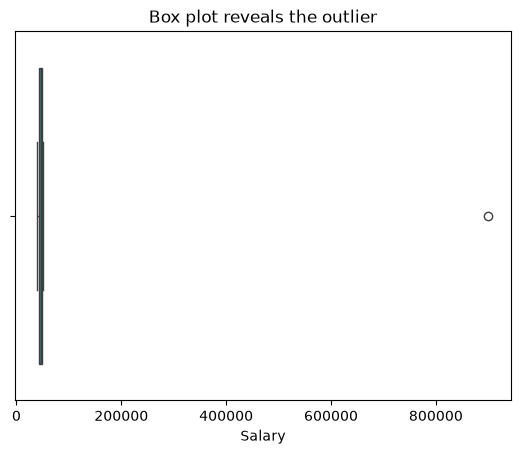

In [23]:
# Visual check
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.boxplot(x=df["Salary"])
plt.title("Box plot reveals the outlier")
plt.show()

### Options once an outlier is found — *investigate first*

In [24]:
o = df.copy()
o["Salary_capped"] = o["Salary"].clip(lower, upper)          # winsorize / cap
o["Salary_flag"] = (o["Salary"] > upper) | (o["Salary"] < lower)  # keep, but flag it
o_removed = o[~o["Salary_flag"]]                                 # remove (only if it is truly an error)
display(o)
print("Rows after removal:", len(o_removed))

,Salary,Salary_capped,Salary_flag
0,40000,40000,False
1,42000,42000,False
2,45000,45000,False
3,47000,47000,False
4,50000,50000,False
5,900000,59000,True


Rows after removal: 5


---
# 1️⃣4️⃣ Standardize Units

`170 cm`, `1.75 m`, `180 cm` cannot be compared without standardization. Convert everything to one unit (here: centimeters). Similar problems: kg/pounds, meters/kilometers, USD/PKR.

In [25]:
h = pd.DataFrame({"Height": ["170 cm", "1.75 m", "180 cm", "5.9 ft"]})

parts = h["Height"].str.extract(r"([\d.]+)\s*(\w+)")
value = pd.to_numeric(parts[0])
unit = parts[1]

factor = unit.map({"cm": 1, "m": 100, "ft": 30.48})
h["Height_cm"] = (value * factor).round(1)
h

,Height,Height_cm
0,170 cm,170.0
1,1.75 m,175.0
2,180 cm,180.0
3,5.9 ft,179.8


---
# 1️⃣5️⃣ Clean Currency Data

`"Rs. 50,000"`, `"PKR 60000"`, `"70,000"` → one numeric format.

In [26]:
cur = pd.DataFrame({"Salary": ["Rs. 50,000", "PKR 60000", "70,000", "  55,000 PKR "]})

cur["Salary"] = (
    cur["Salary"]
    .str.replace("Rs.", "", regex=False)
    .str.replace("PKR", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

cur["Salary"] = pd.to_numeric(
    cur["Salary"],
    errors="coerce"
)
print(cur.dtypes)
cur

Salary    int64
dtype: object


,Salary
0,50000
1,60000
2,70000
3,55000


In [27]:
# A shorter, more robust alternative: keep only digits/decimal point with a regex
raw = pd.Series(["Rs. 50,000", "PKR 60000", "$50,000", "50,000 PKR"])
pd.to_numeric(raw.str.replace(r"[^0-9.]", "", regex=True))

0        0.5
1    60000.0
2    50000.0
3    50000.0
dtype: float64

---
# 1️⃣6️⃣ Rename Columns

Messy: `Student Name`, `student-age`, `SALARY`. Convention: **snake_case**, e.g. `student_name`, `study_hours`, `monthly_salary`, `date_of_birth`.

In [28]:
cols = pd.DataFrame(columns=["Student Name", "student-age", "SALARY"])

cols = cols.rename(columns={
    "Student Name": "student_name",
    "student-age": "student_age",
    "SALARY": "salary"
})
print(list(cols.columns))

['student_name', 'student_age', 'salary']


In [29]:
# Clean ALL column names automatically
weird = pd.DataFrame(columns=[" Student Name ", "Study-Hours", "MONTHLY Salary", "Date Of Birth"])
weird.columns = (
    weird.columns.str.strip()
    .str.lower()
    .str.replace(r"[\s\-]+", "_", regex=True)
)
print(list(weird.columns))

['student_name', 'study_hours', 'monthly_salary', 'date_of_birth']


---
# 1️⃣7️⃣ Remove Unnecessary Columns

Example: `Temporary_ID`, `Unnamed: 0`. But first understand why the column exists.

In [30]:
u = pd.DataFrame({
    "Unnamed: 0": [0, 1, 2],
    "Name": ["Ali", "Ahmed", "Sara"],
    "Temporary_ID": ["x1", "x2", "x3"],
    "Salary": [50000, 55000, 60000],
})

u = u.drop(columns=["Temporary_ID", "Unnamed: 0"])
u

,Name,Salary
0,Ali,50000
1,Ahmed,55000
2,Sara,60000


---
# 1️⃣8️⃣ Boolean / Yes-No Standardization

`Yes, yes, YES, Y, 1, True` → one consistent representation.

In [31]:
yn = pd.DataFrame({"Subscribed": ["Yes", "yes", "YES", "Y", "1", "True", "No", "n", "0", "False"]})

yes_values = {"yes", "y", "1", "true"}
yn["Subscribed_clean"] = yn["Subscribed"].str.strip().str.lower().isin(yes_values)
yn

,Subscribed,Subscribed_clean
0,Yes,True
1,yes,True
2,YES,True
3,Y,True
4,1,True
5,True,True
6,No,False
7,n,False
8,0,False
9,False,False


---
# 1️⃣9️⃣ Handle Special Characters

`"$50,000"`, `"50,000 PKR"`, `"50k"` — convert to consistent numbers before analysis.

In [32]:
def to_number(text):
    text = str(text).lower().strip()
    multiplier = 1000 if text.endswith("k") else 1
    cleaned = "".join(ch for ch in text if ch.isdigit() or ch == ".")
    return float(cleaned) * multiplier if cleaned else np.nan

vals = pd.Series(["$50,000", "50,000 PKR", "50k", "N/A"])
vals.apply(to_number)

0    50000.0
1    50000.0
2    50000.0
3        NaN
dtype: float64

---
# 2️⃣0️⃣ Validate After Cleaning

This step is often forgotten. After cleaning, check again: `info()`, `isnull().sum()`, `duplicated().sum()`, `describe()`, `shape`, `dtypes`.

```text
Are missing values handled?   Are duplicates handled?   Are data types correct?
Are categories consistent?    Are values valid?          Are dates correct?    Are units consistent?
```

Even better — write validation as **assertions** so it fails loudly if something is wrong:

In [33]:
def validate(d):
    assert d.isnull().sum().sum() == 0, "missing values remain"
    assert d.duplicated().sum() == 0, "duplicates remain"
    assert d["age"].between(0, 120).all(), "invalid ages remain"
    assert d["gender"].isin(["Male", "Female"]).all(), "inconsistent gender labels"
    print("✅ All validation checks passed")

demo = pd.DataFrame({"age": [23, 25], "gender": ["Male", "Female"]})
validate(demo)

✅ All validation checks passed


---
# 🧪 The Most Important Data Cleaning Workflow

```text
1. Load Data → 2. Inspect Data → 3. Understand Columns → 4. Check Missing Values
→ 5. Check Duplicates → 6. Check Data Types → 7. Check Unique Values → 8. Standardize Text
→ 9. Fix Invalid Values → 10. Handle Outliers → 11. Standardize Units
→ 12. Remove Unnecessary Data → 13. Validate Everything → 14. Save Clean Dataset
```

---
# 🔍 Useful Inspection Commands

| Purpose                 | Pandas                     |
| ----------------------- | -------------------------- |
| First rows              | `df.head()`                |
| Last rows               | `df.tail()`                |
| Random rows             | `df.sample()`              |
| Dimensions              | `df.shape`                 |
| Column names            | `df.columns`               |
| Data types              | `df.dtypes`                |
| Complete info           | `df.info()`                |
| Statistics              | `df.describe()`            |
| Missing values          | `df.isnull().sum()`        |
| Duplicate rows          | `df.duplicated().sum()`    |
| Unique values           | `df["col"].unique()`       |
| Number of unique values | `df["col"].nunique()`      |
| Category frequency      | `df["col"].value_counts()` |

A reusable "data quality report" function combining them:

In [34]:
def quality_report(d):
    report = pd.DataFrame({
        "dtype": d.dtypes.astype(str),
        "missing": d.isnull().sum(),
        "missing_%": (d.isnull().mean() * 100).round(1),
        "unique": d.nunique(),
    })
    print(f"Shape: {d.shape} | Duplicate rows: {d.duplicated().sum()}")
    return report

quality_report(messy)

Shape: (5, 4) | Duplicate rows: 1


,dtype,missing,missing_%,unique
Name,str,0,0.0,4
Age,float64,1,20.0,3
Gender,str,0,0.0,3
Salary,int64,0,0.0,4


---
# 🧠 The 5 Questions You Should Ask About Every Dataset

1. **What does each column mean?** *Don't clean what you don't understand.*
2. **What is wrong with the data?** Missing, duplicate, invalid, inconsistent, wrong type, outliers.
3. **Why is it wrong?** Extremely important.
4. **What is the correct treatment?** Remove? Replace? Fill? Convert? Keep?
5. **Did my cleaning actually work?** Always validate.

---
# ⚠️ Common Data Cleaning Mistakes

* ❌ Deleting all missing rows immediately.
* ❌ Deleting every outlier.
* ❌ Changing data without understanding it.
* ❌ Using mean for every missing numerical value.
* ❌ Removing duplicates without understanding what a duplicate means.
* ❌ Ignoring data types.
* ❌ Ignoring inconsistent categories.
* ❌ Cleaning but never validating afterward.
* ❌ Modifying the original raw dataset.

---
# ⭐ Professional Tip: Keep Raw Data Safe

```text
data/
├── raw/        └── students.csv
├── cleaned/    └── students_cleaned.csv
└── processed/  └── students_processed.csv

RAW → CLEANED → PROCESSED
```

Never destroy your original raw dataset unless you have a specific reason. In code: work on `df = raw.copy()`.

---
# 🧠 Data Cleaning vs Data Preprocessing

| Data Cleaning              | Data Preprocessing          |
| -------------------------- | --------------------------- |
| Fix missing values         | Scale features              |
| Remove duplicates          | Encode categories           |
| Fix incorrect values       | Feature transformation      |
| Correct data types         | Feature engineering         |
| Standardize text           | Prepare ML input            |
| Handle data quality issues | Transform data for modeling |

```text
Data Cleaning → Make data correct and reliable → Data Preprocessing → Make data suitable for analysis / ML
```

There can be overlap depending on the project and how people use the terms.

---
# 🌍 Real-World Example

Raw data from a company:

```text
1 | Ali    | 23  | Male   | Rs.50,000 | Pakistan
2 | Ahmed  | NaN | male   | 60000     | pakistan
3 | Ali    | 23  | Male   | Rs.50,000 | Pakistan
4 | Sara   | 250 | Female | 70000     | Pakistaan
```

Problems: missing age · duplicate record · gender inconsistency · country inconsistency · impossible age · salary formatting.

In [35]:
raw = pd.DataFrame({
    "customer_id": [1, 2, 3, 4],
    "name":    ["Ali", "Ahmed", "Ali", "Sara"],
    "age":     [23, np.nan, 23, 250],
    "gender":  ["Male", "male", "Male", "Female"],
    "salary":  ["Rs.50,000", "60000", "Rs.50,000", "70000"],
    "country": ["Pakistan", "pakistan", "Pakistan", "Pakistaan"],
})
print("RAW"); display(raw)

clean = raw.copy()                                                       # never touch raw

# text standardization
clean["gender"] = clean["gender"].str.strip().str.title()
clean["country"] = clean["country"].str.strip().str.title().replace({"Pakistaan": "Pakistan"})

# currency -> number
clean["salary"] = pd.to_numeric(clean["salary"].str.replace(r"[^0-9.]", "", regex=True))

# duplicate: same person/details, different customer_id -> compare ignoring the id
clean = clean.drop_duplicates(subset=["name", "age", "gender", "salary", "country"])

# invalid age -> missing, then fill with median of valid ages
clean["age"] = clean["age"].where(clean["age"].between(0, 120))
clean["age"] = clean["age"].fillna(clean["age"].median())

print("CLEAN"); display(clean)

RAW


,customer_id,name,age,gender,salary,country
0,1,Ali,23.0,Male,"Rs.50,000",Pakistan
1,2,Ahmed,NaN,male,60000,pakistan
2,3,Ali,23.0,Male,"Rs.50,000",Pakistan
3,4,Sara,250.0,Female,70000,Pakistaan


CLEAN


,customer_id,name,age,gender,salary,country
0,1,Ali,23.0,Male,0.5,Pakistan
1,2,Ahmed,23.0,Male,60000.0,Pakistan
3,4,Sara,23.0,Female,70000.0,Pakistan


The important part is not just the final table — it is knowing **why each change was made**:

* Age `250` is impossible → treated as missing → filled with the median of valid ages (a business decision; you could also leave it missing or ask the data owner).
* Row 3 repeats row 1 apart from `customer_id` → treated as a duplicate (we had to decide which columns *define* a duplicate).
* `pakistan` / `Pakistaan` are the same country → standardized.

---
# 🧪 Mini Project — Real-World Data Cleaning

Create a messy **Student Performance Dataset** with columns `student_id, name, age, gender, study_hours, attendance, marks, city`, intentionally including: missing values, duplicates, extra spaces, different capitalization, invalid ages, incorrect data types, inconsistent city names, outliers and different formats.

```text
Raw Dataset → Inspection → Missing Values → Duplicates → Data Types → Text Cleaning
→ Invalid Values → Outliers → Standardization → Validation → Clean Dataset
```

### Step 0 — Generate the messy dataset and save `students_raw.csv`

In [36]:
rng = np.random.default_rng(21)
n = 80

cities = ["Islamabad", "Lahore", "Karachi", "Peshawar"]
raw_students = pd.DataFrame({
    "student_id": range(1, n + 1),
    "name": [f"Student {i}" for i in range(1, n + 1)],
    "age": rng.integers(18, 26, n).astype(object),
    "gender": rng.choice(["Male", "Female"], n).astype(object),
    "study_hours": rng.uniform(1, 8, n).round(1).astype(object),
    "attendance": rng.uniform(60, 100, n).round(1).astype(object),
    "marks": (rng.normal(65, 12, n)).clip(20, 100).round(1).astype(object),
    "city": rng.choice(cities, n).astype(object),
})

# ---- inject dirt ----
raw_students.loc[[3, 10, 25], "age"] = np.nan                       # missing
raw_students.loc[[7, 30], "study_hours"] = np.nan
raw_students.loc[[15], "attendance"] = np.nan
raw_students.loc[[5], "gender"] = np.nan
raw_students.loc[[12], "age"] = 200                                  # invalid
raw_students.loc[[20], "age"] = -5                                   # invalid
raw_students.loc[[2, 40], "age"] = ["twenty", "21 yrs"]              # wrong type / format
raw_students.loc[[4, 18], "gender"] = ["male", "FEMALE"]            # inconsistent case
raw_students.loc[[1, 9], "name"] = ["  Student 2 ", "student 10"]   # spaces / case
raw_students.loc[[6, 14, 22], "city"] = ["islamabad", " LAHORE ", "Karachii"]  # inconsistent
raw_students.loc[[33], "marks"] = 950                                # outlier / entry error
raw_students.loc[[44], "marks"] = "78%"                              # format
raw_students.loc[[50], "attendance"] = "85 %"
raw_students = pd.concat([raw_students, raw_students.iloc[[0, 8, 16]]], ignore_index=True)   # duplicates

raw_students.to_csv("students_raw.csv", index=False)
print("Saved students_raw.csv", raw_students.shape)

Saved students_raw.csv (83, 8)


### Step 1 — Inspection

In [37]:
df = pd.read_csv("students_raw.csv")      # always start from the RAW file
display(df.head(8))
df.info()

,student_id,name,age,gender,study_hours,attendance,marks,city
0,1,Student 1,20,Male,1.9,72.4,48.5,Lahore
1,2,Student 2,24,Male,5.9,87.6,48.8,Lahore
2,3,Student 3,twenty,Male,3.3,70.5,67.5,Islamabad
3,4,Student 4,NaN,Male,6.8,71.7,60.0,Lahore
4,5,Student 5,21,male,5.8,62.6,68.0,Islamabad
5,6,Student 6,23,NaN,5.5,71.8,70.9,Lahore
6,7,Student 7,20,Male,5.2,76.4,55.8,islamabad
7,8,Student 8,18,Female,NaN,61.1,62.7,Peshawar


<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   83 non-null     int64  
 1   name         83 non-null     str    
 2   age          80 non-null     str    
 3   gender       82 non-null     str    
 4   study_hours  81 non-null     float64
 5   attendance   82 non-null     str    
 6   marks        83 non-null     str    
 7   city         83 non-null     str    
dtypes: float64(1), int64(1), str(6)
memory usage: 5.3 KB


In [38]:
display(quality_report(df))
for col in ["gender", "city"]:
    print(f"\n{col}:"); print(df[col].value_counts(dropna=False))

Shape: (83, 8) | Duplicate rows: 3


,dtype,missing,missing_%,unique
student_id,int64,0,0.0,80
name,str,0,0.0,80
age,str,3,3.6,12
gender,str,1,1.2,4
study_hours,float64,2,2.4,51
attendance,str,1,1.2,67
marks,str,0,0.0,73
city,str,0,0.0,7



gender:
gender
Male      42
Female    38
male       1
NaN        1
FEMALE     1
Name: count, dtype: int64

city:
city
Lahore       24
Islamabad    21
Karachi      19
Peshawar     16
islamabad     1
 LAHORE       1
Karachii      1
Name: count, dtype: int64


### Step 2 — Standardize column names

In [39]:
df.columns = df.columns.str.strip().str.lower().str.replace(r"\s+", "_", regex=True)
list(df.columns)

['student_id',
 'name',
 'age',
 'gender',
 'study_hours',
 'attendance',
 'marks',
 'city']

### Step 3 — Text cleaning (spaces, case, inconsistent categories)

In [40]:
df["name"] = df["name"].str.strip().str.title()
df["gender"] = df["gender"].str.strip().str.title()
df["city"] = df["city"].str.strip().str.title().replace({"Karachii": "Karachi"})

print(df["gender"].value_counts(dropna=False))
print(df["city"].value_counts())

gender
Male      43
Female    39
NaN        1
Name: count, dtype: int64
city
Lahore       25
Islamabad    22
Karachi      20
Peshawar     16
Name: count, dtype: int64


### Step 4 — Fix data types (strip units/symbols first, then `to_numeric`)

In [41]:
def to_num(series):
    cleaned = series.astype(str).str.replace(r"[^0-9.\-]", "", regex=True)
    return pd.to_numeric(cleaned.replace("", np.nan), errors="coerce")

df["age"] = to_num(df["age"])                       # "twenty" -> NaN, "21 yrs" -> 21
for col in ["study_hours", "attendance", "marks"]:
    df[col] = to_num(df[col])                       # "78%" -> 78, "85 %" -> 85
df.dtypes

student_id       int64
name               str
age            float64
gender             str
study_hours    float64
attendance     float64
marks          float64
city               str
dtype: object

### Step 5 — Duplicates

In [42]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates after :", df.duplicated().sum(), "| rows:", len(df))

Duplicates before: 3
Duplicates after : 0 | rows: 80


### Step 6 — Invalid values (impossible ages → missing)

In [43]:
print("Invalid ages:", df.loc[~df["age"].between(0, 120) & df["age"].notna(), "age"].tolist())
df.loc[~df["age"].between(0, 120), "age"] = np.nan

Invalid ages: [200.0, -5.0]


### Step 7 — Outliers (IQR) — investigate before deciding

In [44]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    i = q3 - q1
    return q1 - 1.5 * i, q3 + 1.5 * i

lo, hi = iqr_bounds(df["marks"])
print(f"marks bounds: ({lo:.1f}, {hi:.1f})")
df[(df["marks"] < lo) | (df["marks"] > hi)]

marks bounds: (36.3, 92.3)


,student_id,name,age,gender,study_hours,attendance,marks,city
33,34,Student 34,19.0,Female,3.6,97.3,950.0,Peshawar


Marks are out of 100, so `950` is **impossible** (probably `95.0` typed wrongly) — that's a data-entry error, not a genuine outlier. Values that are unusual but ≤ 100 would be kept. Here we treat it as missing rather than guessing.

In [45]:
df.loc[~df["marks"].between(0, 100), "marks"] = np.nan
df.loc[~df["attendance"].between(0, 100), "attendance"] = np.nan

### Step 8 — Missing values (each column gets a reasoned strategy)

In [46]:
print(df.isnull().sum())

df["age"] = df["age"].fillna(df["age"].median())               # discrete, small range -> median
df["study_hours"] = df["study_hours"].fillna(df["study_hours"].median())
df["attendance"] = df["attendance"].fillna(df["attendance"].median())
df["marks"] = df["marks"].fillna(df["marks"].mean())           # roughly symmetric after removing the error
df["gender"] = df["gender"].fillna("Unknown")                  # don't invent a gender

df["age"] = df["age"].astype(int)
print("\nMissing after:", df.isnull().sum().sum())

student_id     0
name           0
age            6
gender         1
study_hours    2
attendance     1
marks          1
city           0
dtype: int64

Missing after: 0


### Step 9 — Validation

In [47]:
def validate_students(d):
    assert d.isnull().sum().sum() == 0, "missing values remain"
    assert d.duplicated().sum() == 0, "duplicates remain"
    assert d["age"].between(15, 100).all(), "invalid age"
    assert d["marks"].between(0, 100).all(), "marks out of range"
    assert d["attendance"].between(0, 100).all(), "attendance out of range"
    assert set(d["city"]) <= {"Islamabad", "Lahore", "Karachi", "Peshawar"}, "unknown city labels"
    assert d["gender"].isin(["Male", "Female", "Unknown"]).all(), "bad gender labels"
    print("✅ Validation passed:", d.shape)

validate_students(df)
df.info()

✅ Validation passed: (80, 8)
<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   80 non-null     int64  
 1   name         80 non-null     str    
 2   age          80 non-null     int64  
 3   gender       80 non-null     str    
 4   study_hours  80 non-null     float64
 5   attendance   80 non-null     float64
 6   marks        80 non-null     float64
 7   city         80 non-null     str    
dtypes: float64(3), int64(2), str(3)
memory usage: 5.1 KB


### Step 10 — Save the clean dataset

In [48]:
df.to_csv("students_cleaned.csv", index=False)
print("Saved students_raw.csv and students_cleaned.csv")
df.head()

Saved students_raw.csv and students_cleaned.csv


,student_id,name,age,gender,study_hours,attendance,marks,city
0,1,Student 1,20,Male,1.9,72.4,48.5,Lahore
1,2,Student 2,24,Male,5.9,87.6,48.8,Lahore
2,3,Student 3,21,Male,3.3,70.5,67.5,Islamabad
3,4,Student 4,21,Male,6.8,71.7,60.0,Lahore
4,5,Student 5,21,Male,5.8,62.6,68.0,Islamabad


### Step 11 — EDA on the cleaned data with Seaborn + Matplotlib

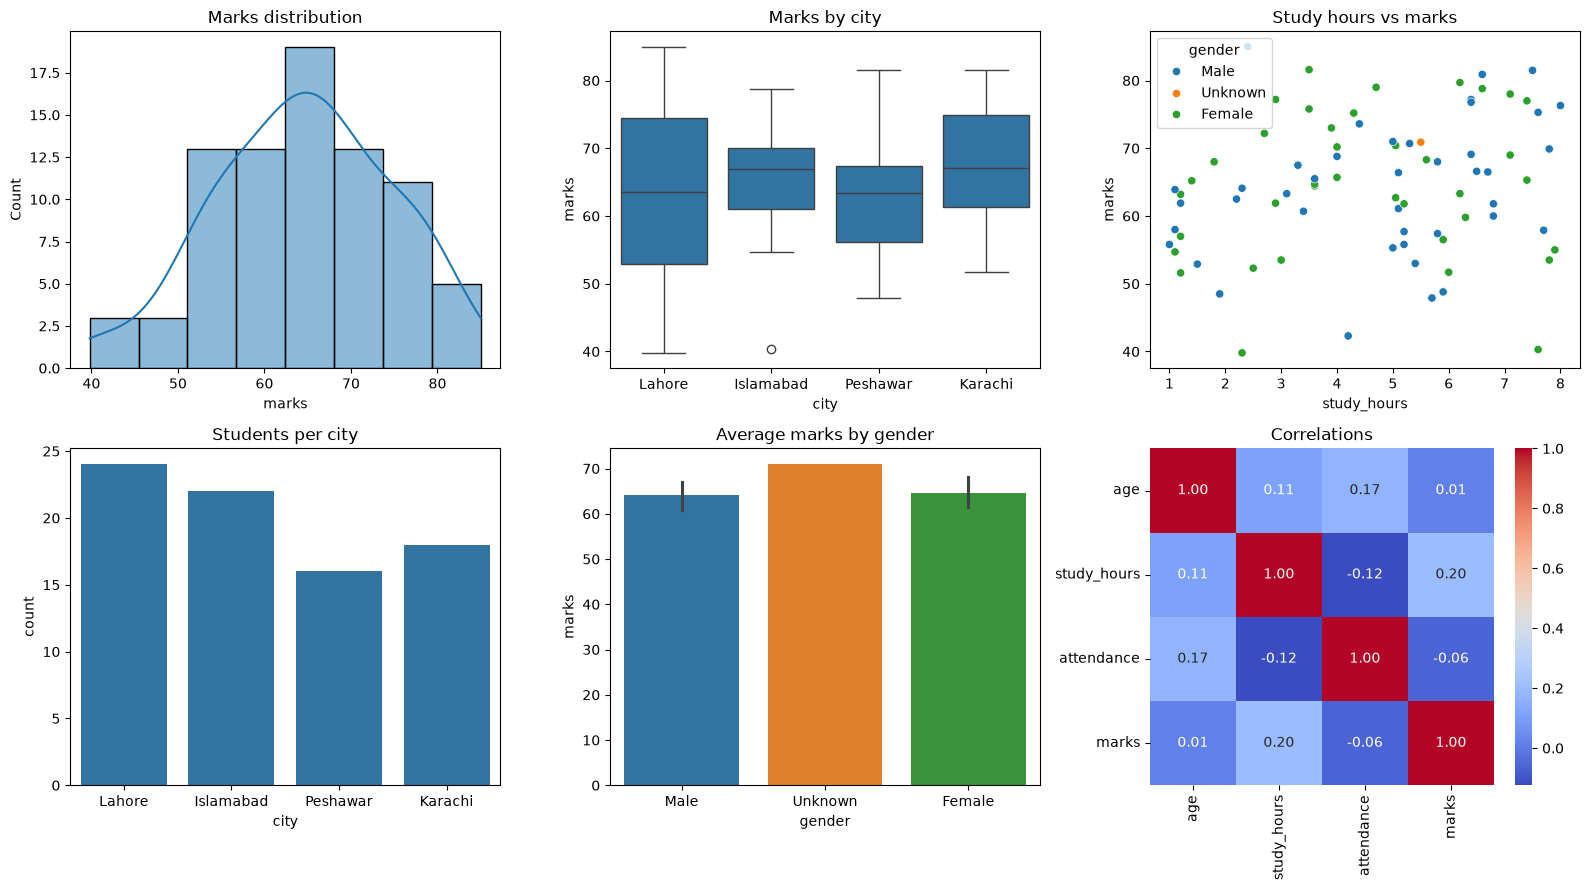

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df["marks"], kde=True, ax=axes[0, 0]);                    axes[0, 0].set_title("Marks distribution")
sns.boxplot(data=df, x="city", y="marks", ax=axes[0, 1]);              axes[0, 1].set_title("Marks by city")
sns.scatterplot(data=df, x="study_hours", y="marks", hue="gender", ax=axes[0, 2]); axes[0, 2].set_title("Study hours vs marks")
sns.countplot(data=df, x="city", ax=axes[1, 0]);                       axes[1, 0].set_title("Students per city")
sns.barplot(data=df, x="gender", y="marks", hue="gender", legend=False, ax=axes[1, 1]); axes[1, 1].set_title("Average marks by gender")
sns.heatmap(df[["age", "study_hours", "attendance", "marks"]].corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[1, 2]); axes[1, 2].set_title("Correlations")

plt.tight_layout()
plt.show()

---
# 🎯 Learning Goals

After completing **Class 21 — Data Cleaning**, you should understand:

- [ ] What Data Cleaning means and why real-world data is messy
- [ ] How to inspect a dataset
- [ ] Missing values · Duplicate records · Incorrect data types
- [ ] Inconsistent categories · Text cleaning · Date cleaning
- [ ] Invalid values · Outliers · The IQR method
- [ ] Unit standardization · Currency cleaning · Column cleaning
- [ ] Removing unnecessary columns
- [ ] Mean vs median
- [ ] Validation
- [ ] Raw vs cleaned data
- [ ] Data Cleaning vs Data Preprocessing
- [ ] The complete cleaning workflow
- [ ] Real-world data quality problems

---
# ✏️ Practice

Write your solutions below each prompt.

**Practice 1 — Missing values.** Build a small DataFrame with missing `Age` (numeric) and `City` (categorical). Fill Age with the median and City with the mode. Explain why.

**Practice 2 — Duplicates.** Create orders where the same customer buys different products. Show that `drop_duplicates()` keeps them but `drop_duplicates(subset=['Customer'])` would wrongly remove data.

**Practice 3 — Currency.** Clean `['Rs. 50,000', 'PKR 60000', '70,000', '$1,200']` into numbers.

**Practice 4 — Categories.** Standardize `['Male','male','MALE',' mAle ','Female','FEMALE ']`.

**Practice 5 — Outliers.** Use the IQR rule on `[40,42,45,47,50,900]` (in thousands). Decide: error or valid? Justify.

**Practice 6 — Full pipeline.** Take `students_raw.csv` and write the whole cleaning process as ONE reusable function `clean_students(raw_df)` that returns the cleaned DataFrame.

---
# ❓ Interview Questions

### Beginner
1. What is Data Cleaning?
2. Why is Data Cleaning important?
3. What are missing values?
4. How do you detect missing values in Pandas?
5. How do you remove duplicates?
6. How do you check data types?
7. What is data validation?

### Intermediate
8. How do you handle missing numerical values?
9. When would you use mean vs median?
10. What is an outlier?
11. Does every outlier need to be removed?
12. What is IQR?
13. How do you handle inconsistent categorical values?
14. How do you clean date columns?
15. How do you convert strings into numerical values?
16. What is the difference between Data Cleaning and Data Preprocessing?

### Practical
17. You have 30% missing values in a column. What would you do?
18. A salary column contains `"Rs. 50,000"`. How would you clean it?
19. A dataset contains `Male`, `male`, `MALE`. How would you standardize it?
20. A customer's age is `250`. What would you do?
21. How would you determine whether a duplicate row is actually a duplicate?
22. How would you validate a cleaned dataset?


---
# 🔑 Key Takeaways

* Data cleaning is **understanding the data**, not just deleting rows.
* Inspect → Understand → Clean → Validate.
* An unusual value is not automatically a bad value; an *impossible* value is.
* Choose mean vs median based on the distribution; use mode or `"Unknown"` for categories.
* Define what a duplicate *means* before removing rows.
* Fix types with `to_numeric(errors="coerce")` / `to_datetime`; standardize text with `str.strip()`, `str.lower()/title()`, `replace()`.
* Keep the raw file untouched; save a cleaned copy; validate with assertions.